In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/wearable_sports_health_dataset (1).csv")

print(df.head())

   Record_ID Athlete_ID            Timestamp  Heart_Rate  Body_Temperature  \
0          1     ATH002  2025-04-10 09:00:00          63              37.1   
1          2     ATH009  2025-04-10 09:05:00          71              37.0   
2          3     ATH001  2025-04-10 09:10:00         131              37.2   
3          4     ATH001  2025-04-10 09:15:00         157              37.5   
4          5     ATH006  2025-04-10 09:20:00          73              36.9   

  Blood_Pressure  Blood_Oxygen  Step_Count Activity_Status   Latitude  \
0         133/78            96         528         Walking  12.927365   
1         128/83            95         330         Running  12.922186   
2         116/90           100         858         Resting  12.922204   
3         135/75           100         732         Cycling  12.922779   
4         112/82            95         667         Cycling  12.926037   

   Longitude  Secure_Transmission_Status  
0  80.116767                           0  
1  80.

In [3]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True)

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

In [4]:
print(df.head())

   Record_ID Athlete_ID            Timestamp  Heart_Rate  Body_Temperature  \
0          1     ATH002  2025-04-10 09:00:00          63              37.1   
1          2     ATH009  2025-04-10 09:05:00          71              37.0   
2          3     ATH001  2025-04-10 09:10:00         131              37.2   
3          4     ATH001  2025-04-10 09:15:00         157              37.5   
4          5     ATH006  2025-04-10 09:20:00          73              36.9   

  Blood_Pressure  Blood_Oxygen  Step_Count Activity_Status   Latitude  \
0         133/78            96         528         Walking  12.927365   
1         128/83            95         330         Running  12.922186   
2         116/90           100         858         Resting  12.922204   
3         135/75           100         732         Cycling  12.922779   
4         112/82            95         667         Cycling  12.926037   

   Longitude  Secure_Transmission_Status  Systolic_BP  Diastolic_BP  
0  80.116767          

In [5]:
np.random.seed(42)

df['Heart_Rate'] = df['Heart_Rate'] + np.random.normal(0, 2, len(df))
df['Body_Temperature'] = df['Body_Temperature'] + np.random.normal(0, 0.1, len(df))
df['Blood_Oxygen'] = df['Blood_Oxygen'] + np.random.normal(0, 0.5, len(df))

In [6]:
def assign_risk(row):
    score = 0

    if row['Heart_Rate'] > 120:
        score += 1
    if row['Blood_Oxygen'] < 95:
        score += 1
    if row['Body_Temperature'] > 37.5:
        score += 1
    if row['Systolic_BP'] > 140:
        score += 1

    # Note: Activity will be handled after encoding
    if score >= 4:
        return 'High Risk'
    elif score >= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Health_Risk'] = df.apply(assign_risk, axis=1)

In [7]:
print(df.head())

   Record_ID Athlete_ID            Timestamp  Heart_Rate  Body_Temperature  \
0          1     ATH002  2025-04-10 09:00:00   63.993428         37.192618   
1          2     ATH009  2025-04-10 09:05:00   70.723471         37.190942   
2          3     ATH001  2025-04-10 09:10:00  132.295377         37.060143   
3          4     ATH001  2025-04-10 09:15:00  160.046060         37.556297   
4          5     ATH006  2025-04-10 09:20:00   72.531693         36.834936   

  Blood_Pressure  Blood_Oxygen  Step_Count Activity_Status   Latitude  \
0         133/78     96.699678         528         Walking  12.927365   
1         128/83     95.462317         330         Running  12.922186   
2         116/90    100.029815         858         Resting  12.922204   
3         135/75     99.676532         732         Cycling  12.922779   
4         112/82     95.349112         667         Cycling  12.926037   

   Longitude  Secure_Transmission_Status  Systolic_BP  Diastolic_BP  \
0  80.116767         

In [8]:
df = pd.get_dummies(df, columns=['Activity_Status'], drop_first=False)

In [9]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df['Health_Risk'] = le_target.fit_transform(df['Health_Risk'])

In [10]:
print(df.head())

   Record_ID Athlete_ID            Timestamp  Heart_Rate  Body_Temperature  \
0          1     ATH002  2025-04-10 09:00:00   63.993428         37.192618   
1          2     ATH009  2025-04-10 09:05:00   70.723471         37.190942   
2          3     ATH001  2025-04-10 09:10:00  132.295377         37.060143   
3          4     ATH001  2025-04-10 09:15:00  160.046060         37.556297   
4          5     ATH006  2025-04-10 09:20:00   72.531693         36.834936   

  Blood_Pressure  Blood_Oxygen  Step_Count   Latitude  Longitude  \
0         133/78     96.699678         528  12.927365  80.116767   
1         128/83     95.462317         330  12.922186  80.115054   
2         116/90    100.029815         858  12.922204  80.115893   
3         135/75     99.676532         732  12.922779  80.112153   
4         112/82     95.349112         667  12.926037  80.118071   

   Secure_Transmission_Status  Systolic_BP  Diastolic_BP  Health_Risk  \
0                           0          133       

In [11]:
base_features = [
    'Heart_Rate',
    'Body_Temperature',
    'Blood_Oxygen',
    'Systolic_BP',
    'Diastolic_BP',
    'Step_Count'
]

activity_features = [col for col in df.columns if 'Activity_Status_' in col]

features = base_features + activity_features

X = df[features]
y = df['Health_Risk']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        93
           1       1.00      0.71      0.83         7

    accuracy                           0.98       100
   macro avg       0.99      0.86      0.91       100
weighted avg       0.98      0.98      0.98       100

Confusion Matrix:

[[93  0]
 [ 2  5]]


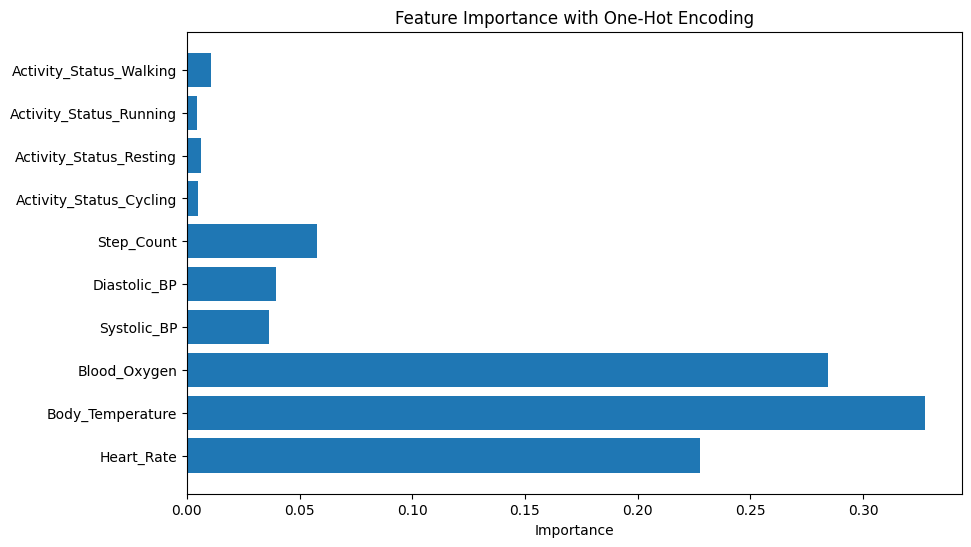

In [16]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance with One-Hot Encoding")
plt.xlabel("Importance")
plt.show()

In [17]:
print("Class Labels:", le_target.classes_)

Class Labels: ['Low Risk' 'Medium Risk']


In [18]:
from joblib import dump

dump(model, 'health_risk_model.pkl')

['health_risk_model.pkl']